In [12]:
import torch
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
import random
from segment_anything import sam_model_registry, SamPredictor

In [14]:
# ==========================
# 🔹 Step 1: Load COCO Data
# ==========================
DATASET_PATH = "./shapes_dataset_16x16/dataset/"
ANNOTATIONS_FILE = DATASET_PATH + "annotations/shapes_coco.json"
IMAGES_PATH = DATASET_PATH + "images/"

# Load COCO annotations
with open(ANNOTATIONS_FILE, "r") as f:
    coco_data = json.load(f)

print(f"✅ Loaded COCO dataset with {len(coco_data['images'])} images and {len(coco_data['annotations'])} annotations.")

✅ Loaded COCO dataset with 100 images and 300 annotations.


In [45]:
import os

print("Checking if dataset path exists:", os.path.exists("./shapes_dataset_16x16/dataset/"))

Checking if dataset path exists: True


In [16]:
# ============================
# 🔹 Step 2: Load Local SAM Model
# ============================
SAM_ROOT = "/Users/ma/Documents/samThesis/segment-anything"
sam_checkpoint = f"{SAM_ROOT}/weights/sam_vit_h_4b8939.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)
print("✅ SAM model loaded successfully!")

✅ SAM model loaded successfully!



🚀 Epoch 1/5 running...
🖼️ Input Image: shapes_17.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
✔ Processing Mask 0: Shape=(16, 16)
✔ Processing Mask 1: Shape=(16, 16)
✔ Processing Mask 2: Shape=(16, 16)
✅ Collected 3 separate masks.
✅ Collected 4 ground truth masks.
🔹 Mask 0 - IoU: 0.2500, Dice Score: 0.4000


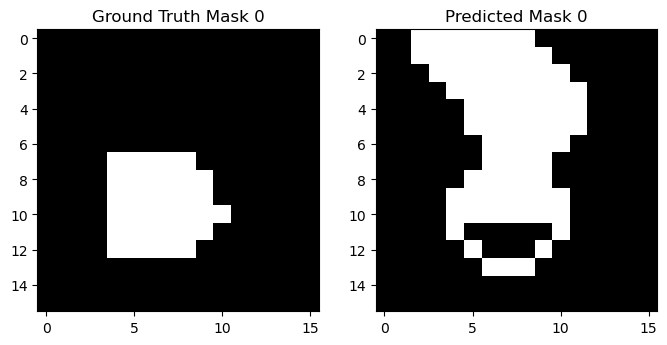

🔹 Mask 1 - IoU: 0.0000, Dice Score: 0.0000


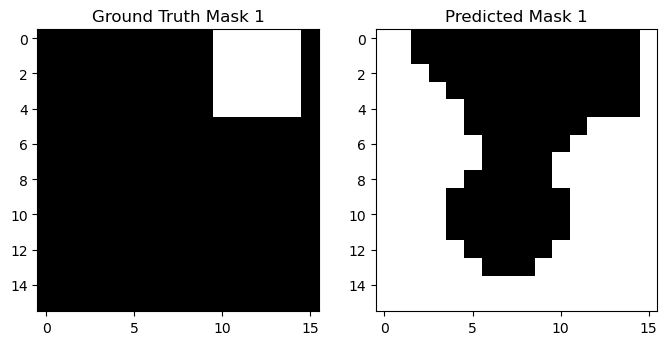

🔹 Mask 2 - IoU: 0.3538, Dice Score: 0.5227


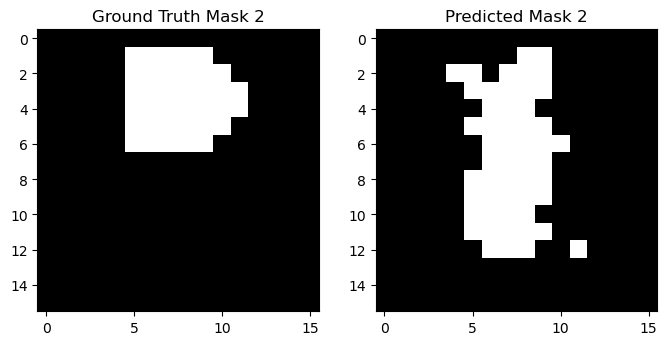


🚀 Epoch 2/5 running...
🖼️ Input Image: shapes_11.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
✔ Processing Mask 0: Shape=(16, 16)
✔ Processing Mask 1: Shape=(16, 16)
✔ Processing Mask 2: Shape=(16, 16)
✅ Collected 3 separate masks.
✅ Collected 2 ground truth masks.
🔹 Mask 0 - IoU: 0.6364, Dice Score: 0.7778


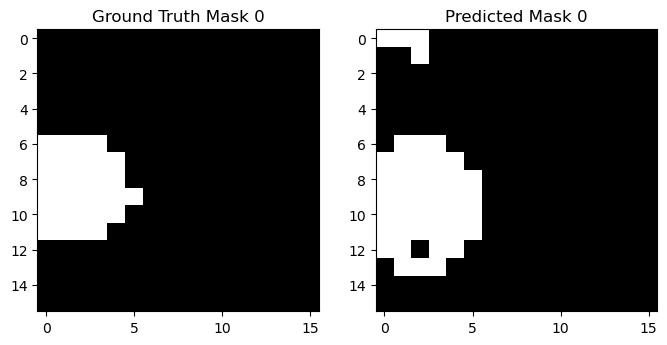

🔹 Mask 1 - IoU: 0.0000, Dice Score: 0.0000


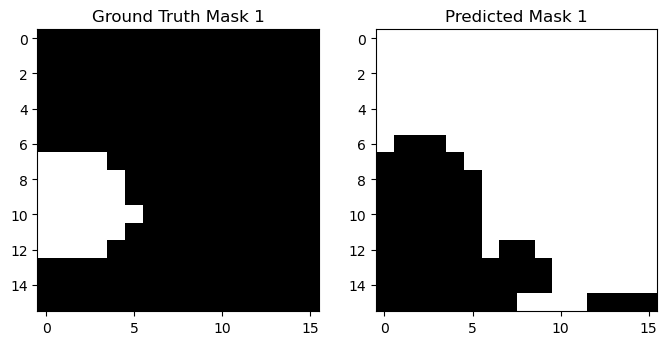


🚀 Epoch 3/5 running...
🖼️ Input Image: shapes_51.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
✔ Processing Mask 0: Shape=(16, 16)
✔ Processing Mask 1: Shape=(16, 16)
✔ Processing Mask 2: Shape=(16, 16)
✅ Collected 3 separate masks.
✅ Collected 3 ground truth masks.
🔹 Mask 0 - IoU: 0.0806, Dice Score: 0.1493


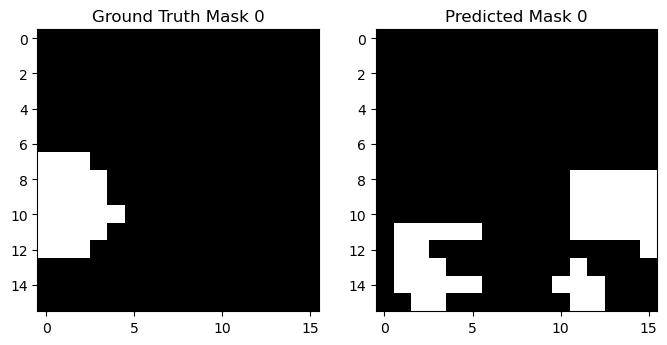

🔹 Mask 1 - IoU: 0.0000, Dice Score: 0.0000


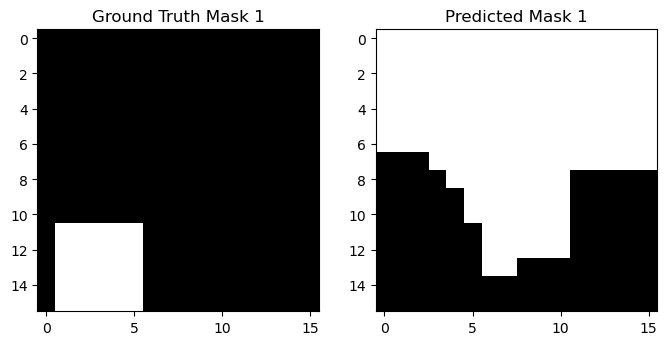

🔹 Mask 2 - IoU: 0.0000, Dice Score: 0.0000


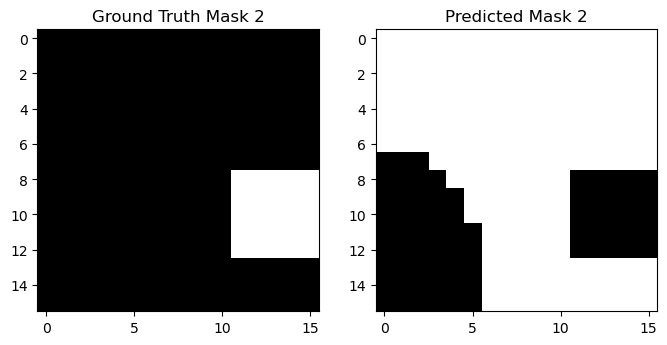


🚀 Epoch 4/5 running...
🖼️ Input Image: shapes_25.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
✔ Processing Mask 0: Shape=(16, 16)
✔ Processing Mask 1: Shape=(16, 16)
✔ Processing Mask 2: Shape=(16, 16)
✅ Collected 3 separate masks.
✅ Collected 4 ground truth masks.
🔹 Mask 0 - IoU: 0.0000, Dice Score: 0.0000


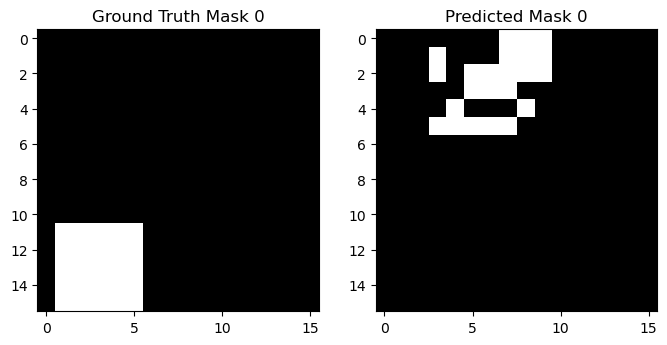

🔹 Mask 1 - IoU: 0.0000, Dice Score: 0.0000


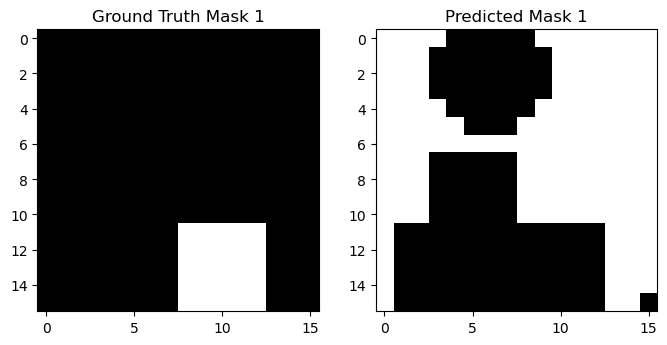

🔹 Mask 2 - IoU: 0.3333, Dice Score: 0.5000


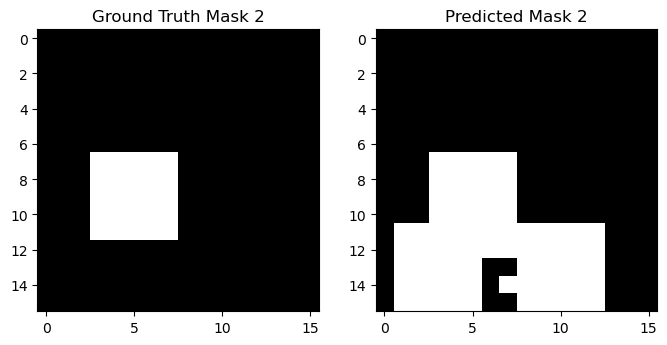


🚀 Epoch 5/5 running...
🖼️ Input Image: shapes_79.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
✔ Processing Mask 0: Shape=(16, 16)
✔ Processing Mask 1: Shape=(16, 16)
✔ Processing Mask 2: Shape=(16, 16)
✅ Collected 3 separate masks.
✅ Collected 2 ground truth masks.
🔹 Mask 0 - IoU: 0.4237, Dice Score: 0.5952


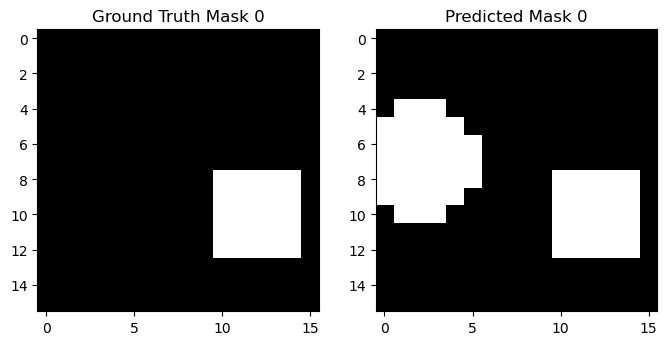

🔹 Mask 1 - IoU: 0.0044, Dice Score: 0.0088


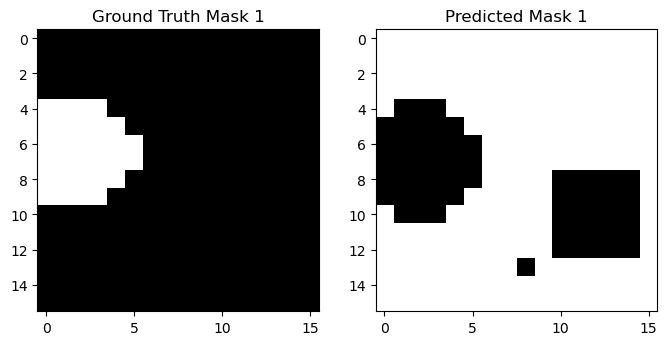

In [29]:
# ============================
# 🔹 Step 3: Run SAM Segmentation
# ============================
NUM_EPOCHS = 5  # Number of test runs

def compute_iou(pred_mask, gt_mask):
    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    union = torch.logical_or(pred_mask, gt_mask).sum().item()
    return intersection / union if union > 0 else 0.0

def compute_dice(pred_mask, gt_mask):
    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    total = pred_mask.sum().item() + gt_mask.sum().item()
    return (2 * intersection) / total if total > 0 else 0.0

epoch_results = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n🚀 Epoch {epoch}/{NUM_EPOCHS} running...")

    # Select a random image
    image_info = random.choice(coco_data["images"])
    image_filename = image_info["file_name"]
    image_path = IMAGES_PATH + image_filename

    # Load Image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print(f"🖼️ Input Image: {image_filename} | Shape Before SAM: {image.shape}")

    # Get annotations for the image
    image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]
    if len(image_annotations) == 0:
        print("❌ No annotations found for this image. Skipping...")
        continue

    # Run SAM
    predictor.set_image(image)
    sam_masks, sam_scores, sam_logits = predictor.predict()

    print(f"✅ Total detected masks: {sam_masks.shape[0]}")  # Number of masks

    # Process Each Mask Separately
    predicted_masks = []

    for i in range(sam_masks.shape[0]):  # Iterate through detected masks
        sam_mask = sam_masks[i]  # Extract the i-th mask

        print(f"✔ Processing Mask {i}: Shape={sam_mask.shape}")

        # Convert SAM mask to torch tensor and store it separately
        predicted_masks.append(torch.tensor(sam_mask).bool())

    print(f"✅ Collected {len(predicted_masks)} separate masks.")

    # Load Ground Truth Mask
    gt_masks = []
    for ann in image_annotations:
        segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)
        segmentation *= np.array([image.shape[1], image.shape[0]])  # Scale
        segmentation = segmentation.astype(np.int32)

        # Create a separate ground truth mask for each annotation
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        cv2.fillPoly(gt_mask, [segmentation], color=1)
        gt_masks.append(torch.tensor(gt_mask).bool())

    print(f"✅ Collected {len(gt_masks)} ground truth masks.")

    # Compare each predicted mask with each GT mask (1:1 evaluation)
    for i, (pred_mask, gt_mask) in enumerate(zip(predicted_masks, gt_masks)):
        # Compute IoU & Dice Scores
        iou_score = compute_iou(pred_mask, gt_mask)
        dice_score = compute_dice(pred_mask, gt_mask)

        epoch_results.append({
            "epoch": epoch,
            "image": image_filename,
            "mask_id": i,
            "iou": iou_score,
            "dice": dice_score
        })

        print(f"🔹 Mask {i} - IoU: {iou_score:.4f}, Dice Score: {dice_score:.4f}")

        # Visualization for each shape
        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(gt_mask.cpu().numpy(), cmap="gray")
        plt.title(f"Ground Truth Mask {i}")
        plt.subplot(1, 2, 2)
        plt.imshow(pred_mask.cpu().numpy(), cmap="gray")
        plt.title(f"Predicted Mask {i}")
        plt.show()

In [31]:
# ============================
# 🔹 Step 4: Print Summary
# ============================

# Print all epoch results
print("\n📊 **Epoch Results Summary**")
for result in epoch_results:
    print(f"Epoch {result['epoch']} - Mask {result['mask_id']}: {result['image']} -> IoU: {result['iou']:.4f}, Dice: {result['dice']:.4f}")



📊 **Epoch Results Summary**
Epoch 1 - Mask 0: shapes_17.png -> IoU: 0.2500, Dice: 0.4000
Epoch 1 - Mask 1: shapes_17.png -> IoU: 0.0000, Dice: 0.0000
Epoch 1 - Mask 2: shapes_17.png -> IoU: 0.3538, Dice: 0.5227
Epoch 2 - Mask 0: shapes_11.png -> IoU: 0.6364, Dice: 0.7778
Epoch 2 - Mask 1: shapes_11.png -> IoU: 0.0000, Dice: 0.0000
Epoch 3 - Mask 0: shapes_51.png -> IoU: 0.0806, Dice: 0.1493
Epoch 3 - Mask 1: shapes_51.png -> IoU: 0.0000, Dice: 0.0000
Epoch 3 - Mask 2: shapes_51.png -> IoU: 0.0000, Dice: 0.0000
Epoch 4 - Mask 0: shapes_25.png -> IoU: 0.0000, Dice: 0.0000
Epoch 4 - Mask 1: shapes_25.png -> IoU: 0.0000, Dice: 0.0000
Epoch 4 - Mask 2: shapes_25.png -> IoU: 0.3333, Dice: 0.5000
Epoch 5 - Mask 0: shapes_79.png -> IoU: 0.4237, Dice: 0.5952
Epoch 5 - Mask 1: shapes_79.png -> IoU: 0.0044, Dice: 0.0088



🚀 Epoch 1/5 running...
🖼️ Input Image: shapes_50.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
🔍 SAM Result Type: <class 'tuple'>
🔍 First Element Type: <class 'numpy.ndarray'>, Shape: (3, 16, 16)
✔ Processing Mask 0: Shape=(16, 16), Confidence=0.5332
✔ Processing Mask 1: Shape=(16, 16), Confidence=0.7404
✔ Processing Mask 2: Shape=(16, 16), Confidence=0.8607
✅ Collected 3 separate predicted masks.
✅ Collected 2 ground truth masks.
🔹 GT Mask 0: Shape Type = 1
🔹 GT Mask 0 vs Pred Mask 0 -> IoU: 0.4464, Dice: 0.6173
🔹 GT Mask 0 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 0 vs Pred Mask 2 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1: Shape Type = 2
🔹 GT Mask 1 vs Pred Mask 0 -> IoU: 0.4286, Dice: 0.6000
🔹 GT Mask 1 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1 vs Pred Mask 2 -> IoU: 0.0000, Dice: 0.0000


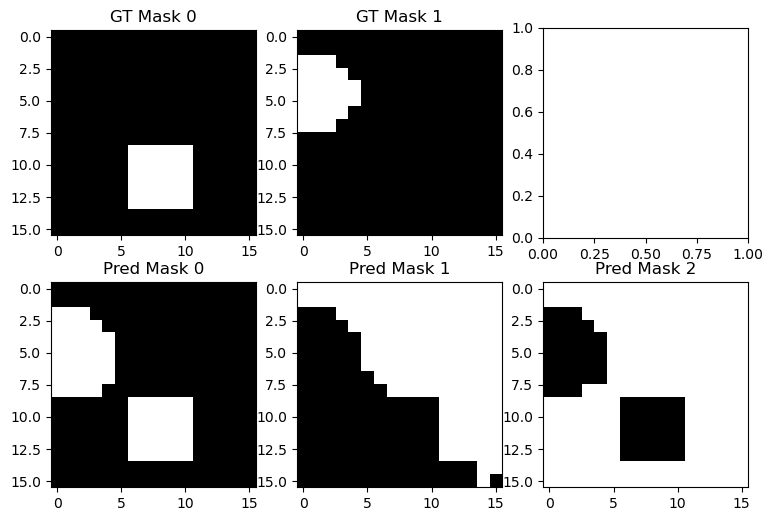


🚀 Epoch 2/5 running...
🖼️ Input Image: shapes_92.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
🔍 SAM Result Type: <class 'tuple'>
🔍 First Element Type: <class 'numpy.ndarray'>, Shape: (3, 16, 16)
✔ Processing Mask 0: Shape=(16, 16), Confidence=0.5027
✔ Processing Mask 1: Shape=(16, 16), Confidence=0.6589
✔ Processing Mask 2: Shape=(16, 16), Confidence=0.8696
✅ Collected 3 separate predicted masks.
✅ Collected 3 ground truth masks.
🔹 GT Mask 0: Shape Type = 1
🔹 GT Mask 0 vs Pred Mask 0 -> IoU: 0.8333, Dice: 0.9091
🔹 GT Mask 0 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 0 vs Pred Mask 2 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1: Shape Type = 2
🔹 GT Mask 1 vs Pred Mask 0 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1 vs Pred Mask 2 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 2: Shape Type = 3
🔹 GT Mask 2 vs Pred Mask 0 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 2 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 2 vs P

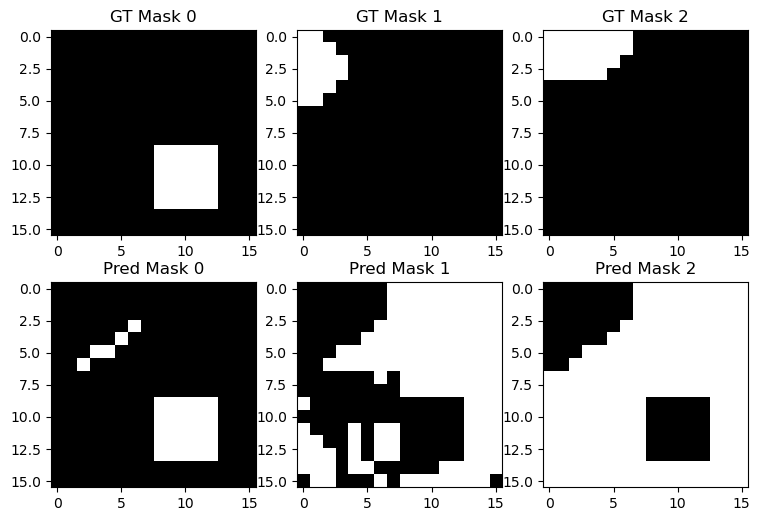


🚀 Epoch 3/5 running...
🖼️ Input Image: shapes_17.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
🔍 SAM Result Type: <class 'tuple'>
🔍 First Element Type: <class 'numpy.ndarray'>, Shape: (3, 16, 16)
✔ Processing Mask 0: Shape=(16, 16), Confidence=0.4592
✔ Processing Mask 1: Shape=(16, 16), Confidence=0.6594
✔ Processing Mask 2: Shape=(16, 16), Confidence=0.8498
✅ Collected 3 separate predicted masks.
✅ Collected 4 ground truth masks.
🔹 GT Mask 0: Shape Type = 1
🔹 GT Mask 0 vs Pred Mask 0 -> IoU: 0.2500, Dice: 0.4000
🔹 GT Mask 0 vs Pred Mask 1 -> IoU: 0.0225, Dice: 0.0440
🔹 GT Mask 0 vs Pred Mask 2 -> IoU: 0.4032, Dice: 0.5747
🔹 GT Mask 1: Shape Type = 2
🔹 GT Mask 1 vs Pred Mask 0 -> IoU: 0.0500, Dice: 0.0952
🔹 GT Mask 1 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1 vs Pred Mask 2 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 2: Shape Type = 3
🔹 GT Mask 2 vs Pred Mask 0 -> IoU: 0.4321, Dice: 0.6034
🔹 GT Mask 2 vs Pred Mask 1 -> IoU: 0.0055, Dice: 0.0109
🔹 GT Mask 2 vs P

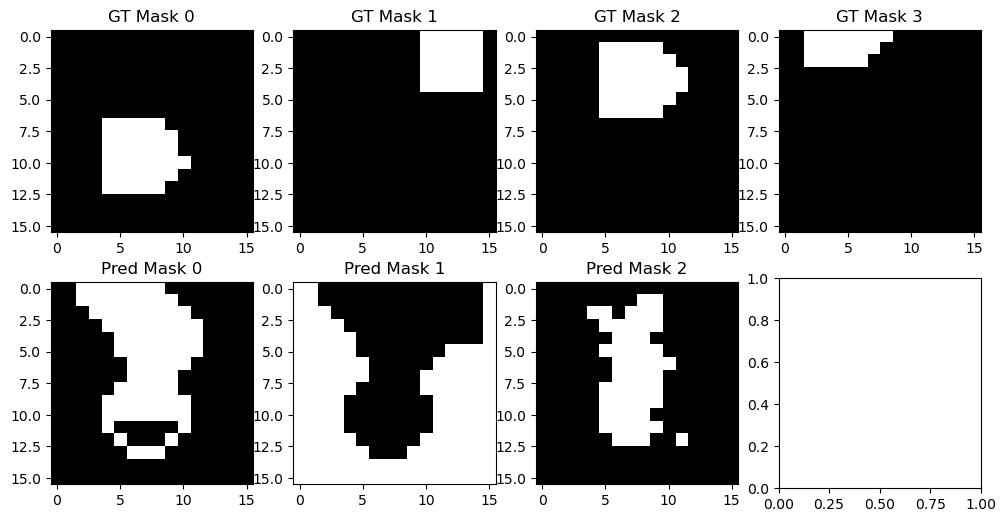


🚀 Epoch 4/5 running...
🖼️ Input Image: shapes_25.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
🔍 SAM Result Type: <class 'tuple'>
🔍 First Element Type: <class 'numpy.ndarray'>, Shape: (3, 16, 16)
✔ Processing Mask 0: Shape=(16, 16), Confidence=0.4873
✔ Processing Mask 1: Shape=(16, 16), Confidence=0.6298
✔ Processing Mask 2: Shape=(16, 16), Confidence=0.8378
✅ Collected 3 separate predicted masks.
✅ Collected 4 ground truth masks.
🔹 GT Mask 0: Shape Type = 1
🔹 GT Mask 0 vs Pred Mask 0 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 0 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 0 vs Pred Mask 2 -> IoU: 0.3333, Dice: 0.5000
🔹 GT Mask 1: Shape Type = 2
🔹 GT Mask 1 vs Pred Mask 0 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1 vs Pred Mask 2 -> IoU: 0.3333, Dice: 0.5000
🔹 GT Mask 2: Shape Type = 3
🔹 GT Mask 2 vs Pred Mask 0 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 2 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 2 vs P

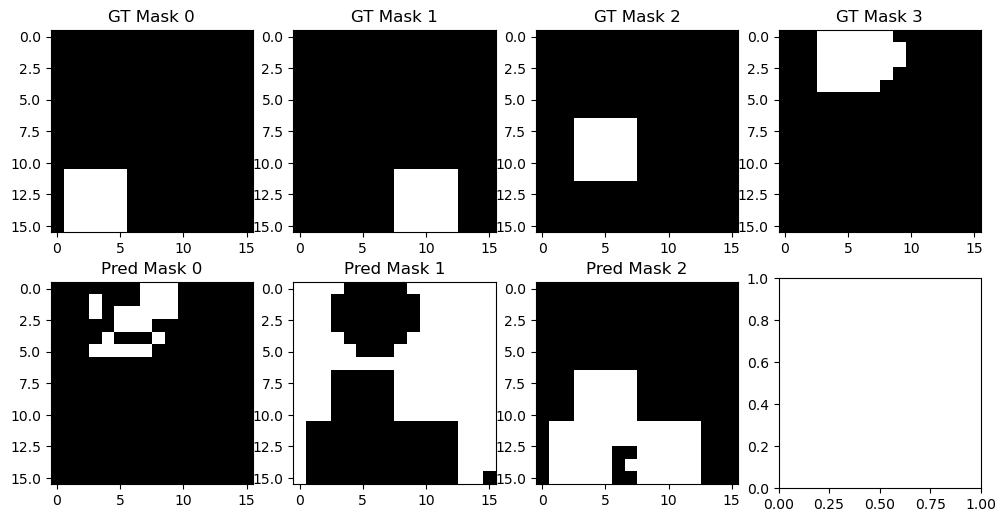


🚀 Epoch 5/5 running...
🖼️ Input Image: shapes_63.png | Shape Before SAM: (16, 16, 3)
✅ Total detected masks: 3
🔍 SAM Result Type: <class 'tuple'>
🔍 First Element Type: <class 'numpy.ndarray'>, Shape: (3, 16, 16)
✔ Processing Mask 0: Shape=(16, 16), Confidence=0.4910
✔ Processing Mask 1: Shape=(16, 16), Confidence=0.6304
✔ Processing Mask 2: Shape=(16, 16), Confidence=0.8160
✅ Collected 3 separate predicted masks.
✅ Collected 3 ground truth masks.
🔹 GT Mask 0: Shape Type = 1
🔹 GT Mask 0 vs Pred Mask 0 -> IoU: 0.3165, Dice: 0.4808
🔹 GT Mask 0 vs Pred Mask 1 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 0 vs Pred Mask 2 -> IoU: 0.0000, Dice: 0.0000
🔹 GT Mask 1: Shape Type = 2
🔹 GT Mask 1 vs Pred Mask 0 -> IoU: 0.3855, Dice: 0.5565
🔹 GT Mask 1 vs Pred Mask 1 -> IoU: 0.0616, Dice: 0.1161
🔹 GT Mask 1 vs Pred Mask 2 -> IoU: 0.0097, Dice: 0.0191
🔹 GT Mask 2: Shape Type = 3
🔹 GT Mask 2 vs Pred Mask 0 -> IoU: 0.3165, Dice: 0.4808
🔹 GT Mask 2 vs Pred Mask 1 -> IoU: 0.2101, Dice: 0.3472
🔹 GT Mask 2 vs P

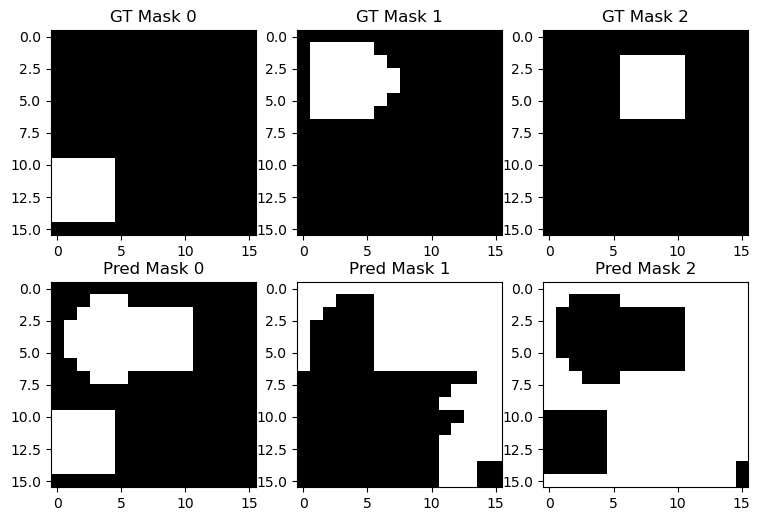

In [39]:
# ============================
# 🔹 Step 3: Run SAM Segmentation (Fixed)
# ============================

import torch
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt

# Define number of epochs
NUM_EPOCHS = 5  

def compute_iou(pred_mask, gt_mask):
    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    union = torch.logical_or(pred_mask, gt_mask).sum().item()
    return intersection / union if union > 0 else 0.0

def compute_dice(pred_mask, gt_mask):
    intersection = torch.logical_and(pred_mask, gt_mask).sum().item()
    total = pred_mask.sum().item() + gt_mask.sum().item()
    return (2 * intersection) / total if total > 0 else 0.0

epoch_results = []

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n🚀 Epoch {epoch}/{NUM_EPOCHS} running...")

    # Select a random image
    image_info = random.choice(coco_data["images"])
    image_filename = image_info["file_name"]
    image_path = IMAGES_PATH + image_filename

    # Load Image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    print(f"🖼️ Input Image: {image_filename} | Shape Before SAM: {image.shape}")

    # Get annotations for the image
    image_annotations = [ann for ann in coco_data["annotations"] if ann["image_id"] == image_info["id"]]
    if len(image_annotations) == 0:
        print("❌ No annotations found for this image. Skipping...")
        continue

    # Run SAM
    predictor.set_image(image)
    sam_result = predictor.predict()
    print(f"✅ Total detected masks: {len(sam_result[0])}")  # Fix: Extracting correct count

    # 🚨 Debug: Inspect SAM output 🚨
    print(f"🔍 SAM Result Type: {type(sam_result)}")
    print(f"🔍 First Element Type: {type(sam_result[0])}, Shape: {sam_result[0].shape}")

    # Extract predicted masks correctly
    predicted_masks = []
    mask_confidences = sam_result[1]  # Confidence scores

    for i in range(sam_result[0].shape[0]):  # Iterate over masks
        pred_mask = sam_result[0][i]  # Extract mask

        print(f"✔ Processing Mask {i}: Shape={pred_mask.shape}, Confidence={mask_confidences[i]:.4f}")

        # Convert to PyTorch tensor
        pred_mask = torch.tensor(pred_mask).bool()
        predicted_masks.append(pred_mask)

    print(f"✅ Collected {len(predicted_masks)} separate predicted masks.")

    # Load Ground Truth Mask
    gt_masks = []
    for ann in image_annotations:
        gt_mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        segmentation = np.array(ann["segmentation"][0]).reshape(-1, 2)
        segmentation *= np.array([image.shape[1], image.shape[0]])  # Scale to pixel coordinates
        segmentation = segmentation.astype(np.int32)

        # Create the GT mask
        cv2.fillPoly(gt_mask, [segmentation], color=1)
        gt_mask = torch.tensor(gt_mask).bool()
        gt_masks.append(gt_mask)

    print(f"✅ Collected {len(gt_masks)} ground truth masks.")

    # Compare each GT mask with each predicted mask
    for gt_idx, gt_mask in enumerate(gt_masks):
        print(f"🔹 GT Mask {gt_idx}: Shape Type = {gt_idx + 1}")  # Debug Shape Type
        for pred_idx, pred_mask in enumerate(predicted_masks):
            iou_score = compute_iou(pred_mask, gt_mask)
            dice_score = compute_dice(pred_mask, gt_mask)
            print(f"🔹 GT Mask {gt_idx} vs Pred Mask {pred_idx} -> IoU: {iou_score:.4f}, Dice: {dice_score:.4f}")

    # Visualization
    num_gt = len(gt_masks)
    num_pred = len(predicted_masks)
    fig, axes = plt.subplots(2, max(num_gt, num_pred), figsize=(max(num_gt, num_pred) * 3, 6))

    for i in range(num_gt):
        axes[0, i].imshow(gt_masks[i].cpu().numpy(), cmap="gray")
        axes[0, i].set_title(f"GT Mask {i}")

    for i in range(num_pred):
        axes[1, i].imshow(predicted_masks[i].cpu().numpy(), cmap="gray")
        axes[1, i].set_title(f"Pred Mask {i}")

    plt.show()
